# Applied Methods of Analysis II: Final Project
Name: Jonas Nepozitek \
Date: x

In [ ]:
import pandas as pd
import wbgapi as wb
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.nonparametric.smoothers_lowess import lowess

## Part I. Title and Executive Summary

### Effects of the Share of Manufacturing and Institutional Capacity on Weathering the 2008 Financial Crisis in the EU

### Executive Summary
...

## Part II. Question Motivation & Background

...

## Part III. Data Description

In [85]:
# EU and Eurozone countries for 2007
eu = [
    'AUT',  # Austria
    'BEL',  # Belgium
    'BGR',  # Bulgaria
    'CYP',  # Cyprus
    'CZE',  # Czech Republic
    'DNK',  # Denmark
    'EST',  # Estonia
    'FIN',  # Finland
    'FRA',  # France
    'DEU',  # Germany
    'GRC',  # Greece
    'HUN',  # Hungary
    'IRL',  # Ireland
    'ITA',  # Italy
    'LVA',  # Latvia
    'LTU',  # Lithuania
    'LUX',  # Luxembourg
    'MLT',  # Malta
    'NLD',  # Netherlands
    'POL',  # Poland
    'PRT',  # Portugal
    'ROU',  # Romania
    'SVK',  # Slovakia
    'SVN',  # Slovenia
    'ESP',  # Spain
    'SWE',  # Sweden
    'GBR',  # United Kingdom
]

eurozone = [
    'AUT', 'BEL', 'FIN', 'FRA', 
    'DEU', 'GRC', 'IRL', 'ITA',
    'LUX', 'NLD', 'PRT', 'SVN',
    'ESP'
]

# WB data
gdppp = wb.data.DataFrame('NY.GDP.PCAP.PP.CD')
gdppp = gdppp.iloc[:,-19:-10]
gdppp = gdppp[gdppp.index.isin(eu)]

unemployment = wb.data.DataFrame('SL.UEM.TOTL.ZS')
unemployment = unemployment.iloc[:,-19:-10]
unemployment = unemployment[unemployment.index.isin(eu)]

manufacturing = wb.data.DataFrame('NV.IND.MANF.ZS')
manufacturing = manufacturing.iloc[:,-19:-10]
manufacturing = manufacturing[manufacturing.index.isin(eu)]

credit = wb.data.DataFrame('FS.AST.PRVT.GD.ZS')
credit = credit.iloc[:,-19:-10]
credit = credit[credit.index.isin(eu)]

lending = wb.data.DataFrame('GC.NLD.TOTL.GD.ZS')
lending = lending.iloc[:,-19:-10]
lending = lending[lending.index.isin(eu)]

# WGI data
wgi = pd.read_excel('inputs/Raw Data from Underlying Data Sources (1996-2024).xlsx', sheet_name='GE')

wgi = wgi[
    (wgi['indicator'] == 'average of all ge indicators')
    & (wgi['DataSourceCode'] == 'EIU')
    & (wgi['econ_code'].isin(eu))
    & (wgi['production_year'] >= 2007)
    & (wgi['production_year'] <= 2015)
][['econ_code', 'production_year', 'value']].pivot(index='econ_code', columns='production_year', values='value')

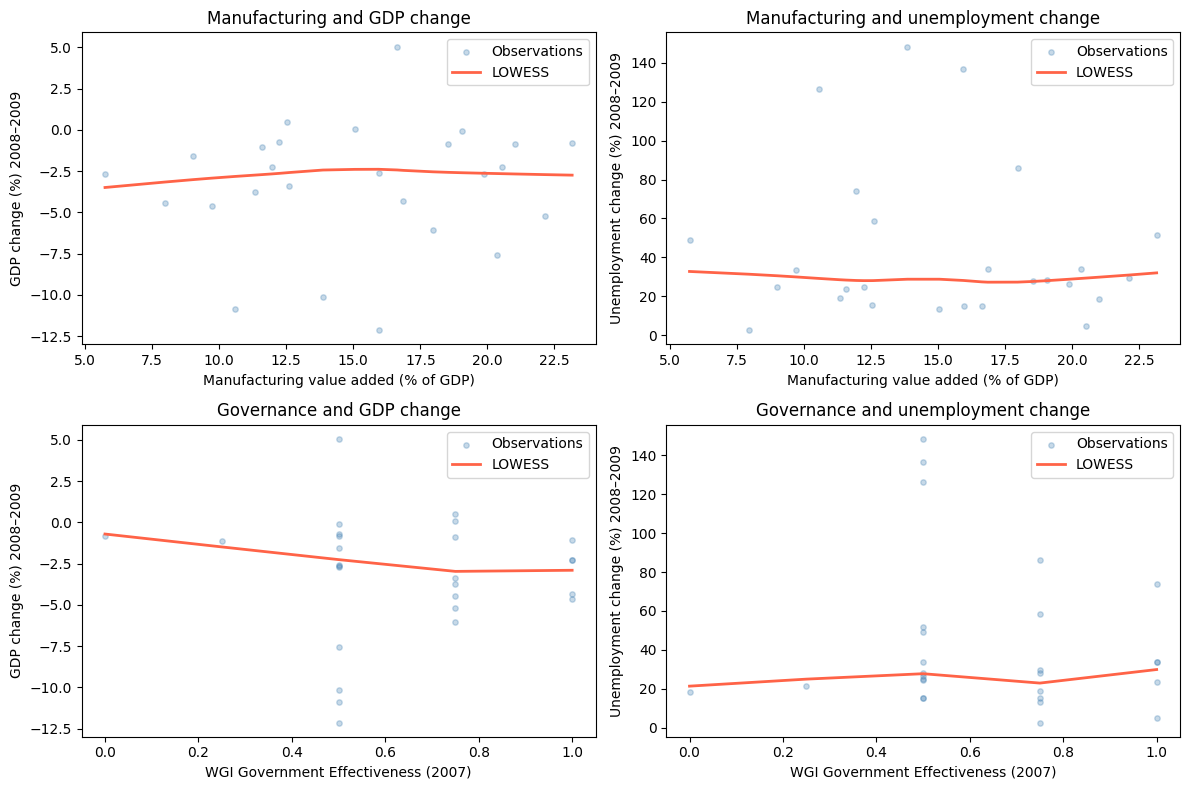

In [106]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()  # flatten to 1D: 0,1,2,3

# 1) Manuf vs GDP change
gdp_change = (gdppp["YR2009"] - gdppp["YR2008"]) / gdppp["YR2008"] * 100
sm = lowess(gdp_change, manufacturing["YR2007"], frac=0.9)

ax = axes[0]
ax.scatter(manufacturing["YR2007"], gdp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('Manufacturing value added (% of GDP)')
ax.set_ylabel('GDP change (%) 2008–2009')
ax.set_title('Manufacturing and GDP change')
ax.legend()

# 2) Manuf vs Unemployment change
unemp_change = (unemployment["YR2009"] - unemployment["YR2008"]) / unemployment["YR2008"] * 100
sm = lowess(unemp_change, manufacturing["YR2007"], frac=0.9)

ax = axes[1]
ax.scatter(manufacturing["YR2007"], unemp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('Manufacturing value added (% of GDP)')
ax.set_ylabel('Unemployment change (%) 2008–2009')
ax.set_title('Manufacturing and unemployment change')
ax.legend()

# 3) WGI vs GDP change
sm = lowess(gdp_change, wgi[2007], frac=0.9)

ax = axes[2]
ax.scatter(wgi[2007], gdp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('WGI Government Effectiveness (2007)')
ax.set_ylabel('GDP change (%) 2008–2009')
ax.set_title('Governance and GDP change')
ax.legend()

# 4) WGI vs Unemployment change
sm = lowess(unemp_change, wgi[2007], frac=0.9)

ax = axes[3]
ax.scatter(wgi[2007], unemp_change, alpha=0.3, s=15,
           color='steelblue', label='Observations')
ax.plot(sm[:, 0], sm[:, 1], color='tomato', linewidth=2, label='LOWESS')
ax.set_xlabel('WGI Government Effectiveness (2007)')
ax.set_ylabel('Unemployment change (%) 2008–2009')
ax.set_title('Governance and unemployment change')
ax.legend()

plt.tight_layout()
plt.savefig("outputs/data_description.png", dpi=300, bbox_inches="tight")
plt.show()

## Part IV. Methodology

...

## Part V. Key Results

...

## Part VI. Summary Conclusion

...

## Part VII. References

...